In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns

In [17]:
data_dir=Path("../../data/adapt").resolve()
log_dir=data_dir/"full_run_2026-05-05_17:30:17"
print(log_dir)

/hkfs/work/workspace_haic/scratch/hgf_dsb0249-BinderDesign/flexcraft/data/adapt/full_run_2026-05-05_17:30:17


In [ ]:
# intervention: bug caused removal to fail
# current length: 950 designs
# taking 400 best scoring designs
# resuming without design for 19 more hours
scores = pd.read_csv(log_dir/"scores.csv", index_col=0)
scores["in_pool"] = False
scores.loc[scores.sort_values("score").iloc[:400].index, "in_pool"]=True
scores.sort_values("score").iloc[:400]["scaffold"].map(lambda x: x.split("+")[0]).value_counts()
scores.to_csv(log_dir/"scores.csv")

============================= JOB FEEDBACK =============================

Job ID: 1642123

Cluster: haic

User/Group: hgf_dsb0249/hgf_dkfz

Account: hgf_dkfz

State: CANCELLED (exit code 0)

Partition: normal

Nodes: 1

Cores per node: 8

Nodelist: haicn1710

CPU Utilized: 00:00:02

CPU Efficiency: 0.00% of 1-17:17:36 core-walltime

Job Wall-clock time: 05:09:42

Starttime: Tue May  5 17:30:05 2026

Endtime: Tue May  5 22:39:47 2026

Memory Utilized: 7.61 GB

Memory Efficiency: 25.36% of 30.00 GB (30.00 GB/node)

Energy Consumed: 17594683 Joule / 4887.41194444444 Watthours

Average node power draw: 946.867021849101 Watt



In [23]:
df = pd.read_csv(log_dir/"scores.csv")
df.columns = ["design"]+df.columns.to_list()[1:]
print(f"{df['in_pool'].sum()}/{df.shape[0]} structures in pool!")
#df = df[df["in_pool"]]
df["time"] = df["time"].map(lambda x: (datetime.now()-datetime.strptime(x,"%Y-%d-%b_%H:%M:%S")).total_seconds())


886/887 structures in pool!


In [33]:
df["scaffold"].value_counts()

scaffold
7N2R+MAVMAPRTLV+TLMSAMTNL+CALSGASKII+CASSRRRGRR    4
3GSN+MAVMAPRTLV+TLMSAMTNL+CAGSISSGSA+CASSLQSSYN    3
5BS0+MAVMAPRTLV+TLMSAMTNL+CVVNTRSGGY+CASSQGLAST    3
5BS0+MAVMAPRTLV+TLMSAMTNL+CARRGYGQNF+CAWSKTSYEQ    3
5BS0+MAVMAPRTLV+TLMSAMTNL+CALSEAGGQN+CASSLPSGGG    3
                                                  ..
7OW6+MAVMAPRTLV+TLMSAMTNL+CGTENRAGNQ+CASSLLQGAP    1
7OW6+MAVMAPRTLV+TLMSAMTNL+CVVNGDTDKL+CSARDQAATD    1
7OW6+MAVMAPRTLV+TLMSAMTNL+CLVGDSSYNT+CSARLWGEAG    1
7OW6+MAVMAPRTLV+TLMSAMTNL+CAVNVRGGSN+CATSPLGNYG    1
7OW6+MAVMAPRTLV+TLMSAMTNL+CIVRVGKAAA+CASSQIPDLN    1
Name: count, Length: 800, dtype: int64

In [32]:
df[df["scaffold"]==df[~df["in_pool"]].scaffold.values[0]]

,design,score,scaffold,time,in_pool,tcr_chain_index,mhc_chain_index,acdr1,acdr2,acdr3,bcdr1,bcdr2,bcdr3,acdr1_coords,acdr2_coords,acdr3_coords,bcdr1_coords,bcdr2_coords,bcdr3_coords
140,5BS0+MAVMAPRTLV+TLMSAMTNL+CALSEARRGS+CASSSGLAG...,5.449935,5BS0+MAVMAPRTLV+TLMSAMTNL+CALSEARRGS+CASSSGLAGV,14661.206154,False,"(0, 1)","(3,)",ESALW,YCRWGC,VALDEVPLGNLPGLLRS,SIKC,WQSHT,EGTDLSPPLMLPLPGLTLRS,"(26, 31)","(49, 55)","(90, 107)","(25, 29)","(47, 52)","(90, 110)"


In [34]:
df.loc[df["score"].argmax()]

design             5BS0+MAVMAPRTLV+TLMSAMTNL+CALSEARRGS+CASSSGLAG...
score                                                       5.449935
scaffold             5BS0+MAVMAPRTLV+TLMSAMTNL+CALSEARRGS+CASSSGLAGV
time                                                    14661.206154
in_pool                                                        False
tcr_chain_index                                               (0, 1)
mhc_chain_index                                                 (3,)
acdr1                                                          ESALW
acdr2                                                         YCRWGC
acdr3                                              VALDEVPLGNLPGLLRS
bcdr1                                                           SIKC
bcdr2                                                          WQSHT
bcdr3                                           EGTDLSPPLMLPLPGLTLRS
acdr1_coords                                                (26, 31)
acdr2_coords                      

In [5]:
intervall = 10
bins = np.arange(0, ((df["time"].max()//intervall)+2)*intervall, intervall)
i = np.arange(len(bins))
df["binned_time"] = df["time"].map(lambda x: i[bins>x][0]*intervall)

In [6]:
bins

array([0.000e+00, 1.000e+01, 2.000e+01, ..., 1.629e+04, 1.630e+04,
       1.631e+04], shape=(1632,))

(array([ 1.,  1.,  2.,  2.,  2.,  3.,  6.,  9.,  9.,  9., 17., 14., 17.,
        18., 21., 29., 22., 25., 18., 16., 30., 29., 37., 27., 40., 17.,
        32., 22., 23., 28., 24., 18., 25., 11., 21., 14., 11., 16.,  9.,
         9., 10.,  6., 13.,  8., 10., 16.,  9.,  4.,  7.,  4.,  6.,  4.,
         4.,  7.,  1.,  1.,  0.,  0.,  4.,  3.,  2.,  0.,  3.,  3.,  0.,
         2.,  3.,  2.,  0.,  0.,  0.,  2.,  3.,  0.,  0.,  1.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  1.,  0.,  0.,  2.]),
 array([1.5069776 , 1.54355583, 1.58013406, 1.61671229, 1.65329052,
        1.68986875, 1.72644698, 1.76302521, 1.79960344, 1.83618167,
        1.8727599 , 1.90933813, 1.94591636, 1.98249459, 2.01907282,
        2.05565105, 2.09222928, 2.12880751, 2.16538574, 2.20196397,
        2.2385422 , 2.27512043, 2.31169866, 2.34827689, 2.38485512,
        2.42143335, 2.45801158, 2.49458981, 2.53116804, 2.56774627,
        2.6043245 , 2.6409

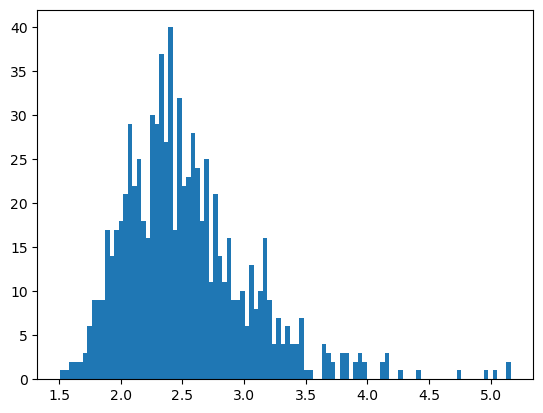

In [7]:
plt.hist(df["score"], bins=100)

<Axes: xlabel='binned_time'>

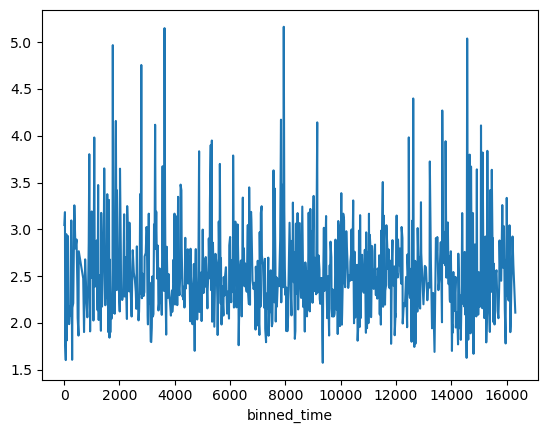

In [8]:
means = df.groupby("binned_time")["score"].agg("median")
means.plot()

In [9]:
sns.lineplot(
    means,
    x="binned_time",
    y="score",
    #hue="scaffold",
    #legend=False
)

TypeError: Data source must be a DataFrame or Mapping, not <class 'pandas.Series'>.